<a href="https://colab.research.google.com/github/Priyanshu01Tayal/Supervised-Learning-Practice/blob/main/Studentperformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [9]:
data=pd.read_csv("student.csv")

In [10]:
print(data)

    Student_ID  Gender  Age  Attendance_Percent  Study_Hours_Per_Day  \
0       ST0001    Male   17                  88                  5.4   
1       ST0002  Female   19                  78                  4.1   
2       ST0003    Male   21                  64                  4.9   
3       ST0004  Female   21                  92                  6.0   
4       ST0005  Female   22                  57                  4.7   
..         ...     ...  ...                 ...                  ...   
995     ST0996  Female   21                  69                  2.4   
996     ST0997    Male   22                  74                  6.4   
997     ST0998  Female   20                  53                  7.0   
998     ST0999  Female   17                  59                  5.1   
999     ST1000  Female   17                  52                  4.3   

     Assignments_Completed  Previous_Grade Participation Internet_Access  \
0                        3              48          High   

In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_label=data.copy()
df_label['gender_en']=le.fit_transform(df_label['Gender'])
df_label['Participation-en']=le.fit_transform(df_label['Participation'])
df_label['Family_Income_en']=le.fit_transform(df_label['Family_Income'])




In [13]:
print(df_label)

    Student_ID  Gender  Age  Attendance_Percent  Study_Hours_Per_Day  \
0       ST0001    Male   17                  88                  5.4   
1       ST0002  Female   19                  78                  4.1   
2       ST0003    Male   21                  64                  4.9   
3       ST0004  Female   21                  92                  6.0   
4       ST0005  Female   22                  57                  4.7   
..         ...     ...  ...                 ...                  ...   
995     ST0996  Female   21                  69                  2.4   
996     ST0997    Male   22                  74                  6.4   
997     ST0998  Female   20                  53                  7.0   
998     ST0999  Female   17                  59                  5.1   
999     ST1000  Female   17                  52                  4.3   

     Assignments_Completed  Previous_Grade Participation Internet_Access  \
0                        3              48          High   

In [16]:
X=df_label[['Attendance_Percent','Study_Hours_Per_Day','Assignments_Completed','Previous_Grade','Participation-en','Family_Income_en']]
y=df_label['Exam_Score']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [19]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

3.8988610578166982
22.883048199275272
4.783622915664996


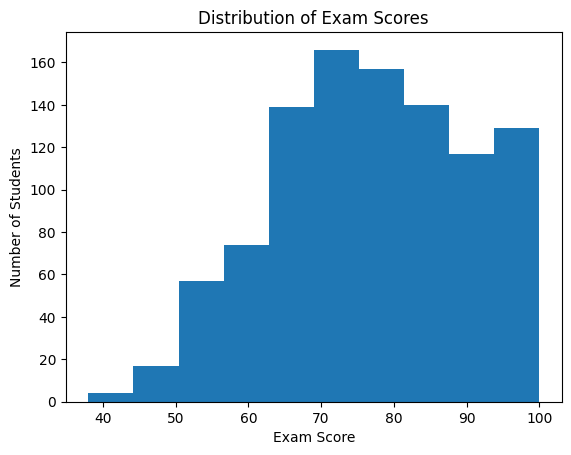

In [21]:
plt.hist(df_label['Exam_Score'], bins=10)
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")
plt.show()

In [22]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.874151415062007


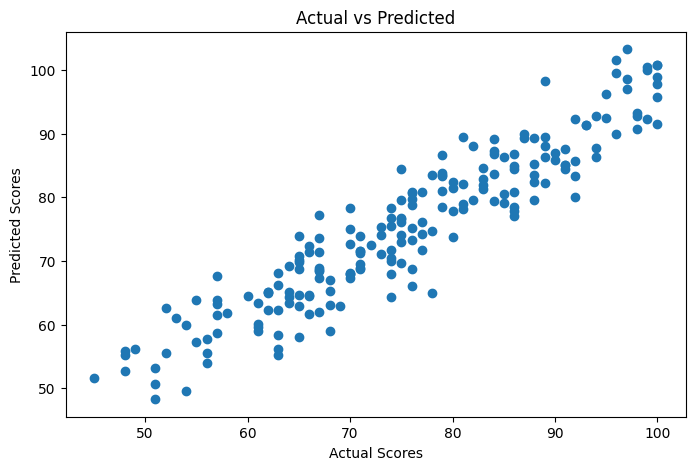

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")
plt.show()

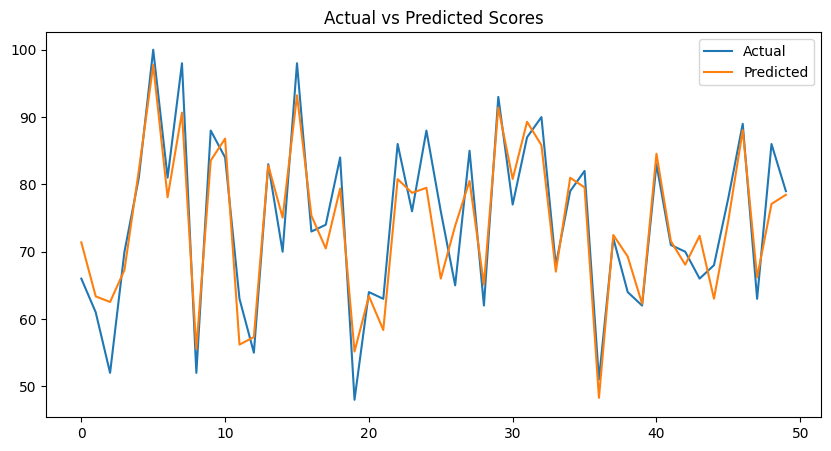

In [24]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Scores")
plt.show()